Multiple Linear Regression: Gradient Descent with multiple variables

X_train: (m examples,n features)

y_train: targets

W: vector(n parameters)

b: scalar number(parameters)

alpha: learning rate

model: f_Wb = W.X+b  (dot product w1*x1 + ---- + wn*xn)

cost: J_Wb = (1/(2m)) * summation of (f_Wb_i - y[i])**2

gradient: dj_dw_j = (1/m) * summation of (f_Wb_i - y[i]) * x[i,j]

.................

         dj_db = (1/m) * summation of (f_wb_i - y[i])

gradient descent: W1 = W1 - alpha * dj_dw1

.................Wn = Wn - alpha * dj_dwn

                b = b - alpha * dj_db               


In [58]:
import copy, math 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
np.set_printoptions(precision=2)

In [59]:
# x = [size(sqft),bed room, floor,year] = x1=size,x2=bed,x3=floor,x4=year,y=target
X_train = np.array([[2104,5,1,45],[1416,3,2,40],[852,2,1,35]])
y_train = np.array([460,232,178])
W_in = np.array([0.39133535, 18.75376741, -53.36032453, -26.42131618])
b_in = 785.1811367994083

In [60]:
def f_wb(x,w,b):
    predict = np.dot(w,x) + b 
    return predict
f_wb(X_train[0],W_in,b_in)

459.9999976194083

In [61]:
def J_wb(x,y,w,b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb_i = np.dot(w,x[i]) + b
        cost += (f_wb_i - y[i])**2
    return cost/(2*m)
J_wb(X_train,y_train,W_in,b_in)

1.5578904045996674e-12

In [62]:
def gradient(x,y,w,b):
    m,n = x.shape
    dj_dw = np.zeros(n)
    dj_db = 0

    for i in range(m):
        err = (np.dot(w,x[i]) + b) - y[i]

        for j in range(n):
            dj_dw[j] += err * x[i,j]

        dj_db += err
    
    return dj_dw/m , dj_db/m 
            
gradient(X_train,y_train,W_in,b_in)

(array([-2.73e-03, -6.27e-06, -2.22e-06, -6.92e-05]), -1.6739251122999121e-06)

In [63]:
def gradient_dest(x,y,w_init,b_init,alpha,iteration,cost_func,gradient_func):
    w = copy.deepcopy(w_init)
    b = b_init
    J_hist = []
    progress = []
    for i in range(iteration):
        dj_dw_i,dj_db_i = gradient_func(x,y,w,b)

        w = w - (alpha * dj_dw_i)
        b = b - alpha * dj_db_i

        if i<100000:
            J_hist.append(cost_func(x,y,w,b))
        
        if i % math.ceil(iteration/10) == 0:
            progress.append({
                "iter": i,
                "cost": J_hist[-1]
            })
            
    return w,b,J_hist,progress


In [64]:
initial_w = np.zeros_like(W_in)
initial_b = 0.0
alpha = 5.0e-7
iter = 1000
w_final,b_final,J_hist,progress = gradient_dest(X_train,y_train,initial_w,initial_b,alpha,iter,J_wb,gradient)
print(f"W Fianl: {w_final}")
print(f"b fianl: {b_final}")

df = pd.DataFrame(progress)
print(df)


W Fianl: [ 0.2   0.   -0.01 -0.07]
b fianl: -0.0022354075309325345
   iter         cost
0     0  2529.462952
1   100   695.990316
2   200   694.920698
3   300   693.860430
4   400   692.809429
5   500   691.767612
6   600   690.734900
7   700   689.711210
8   800   688.696464
9   900   687.690581


In [65]:
m,_ = X_train.shape
for i in range(m):
    predict = f_wb(w_final,X_train[i],b_final)

    print(f"House price prediction: ${predict:.0f}, Actual price: {y_train[i]}")

House price prediction: $426, Actual price: 460
House price prediction: $286, Actual price: 232
House price prediction: $171, Actual price: 178


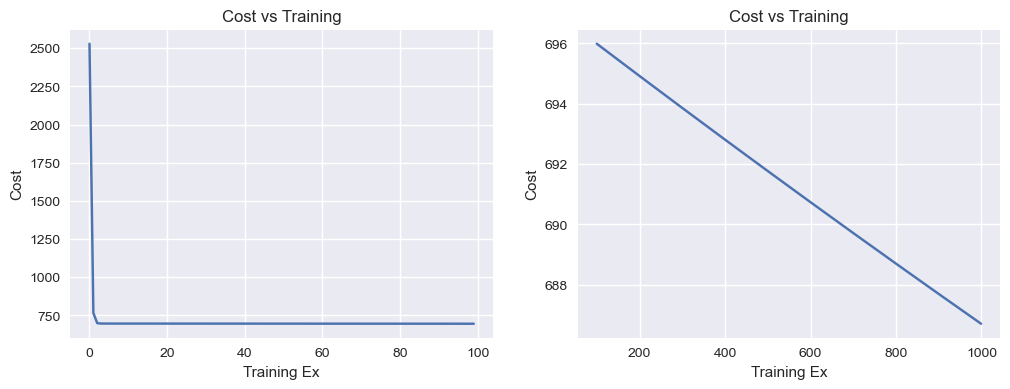

In [66]:
figure,(axe1,axe2) = plt.subplots(1,2,figsize=(12,4))
axe1.plot(J_hist[0:100])
axe2.plot(100+np.arange(len(J_hist[100:])),J_hist[100:])
axe1.set_title("Cost vs Training")
axe2.set_title("Cost vs Training")
axe1.set_xlabel("Training Ex")
axe2.set_xlabel("Training Ex")
axe1.set_ylabel("Cost")
axe2.set_ylabel("Cost")
plt.show()